# Étude — Volume vs efficacité : qu’est-ce qui influence vraiment le draft ?

Ce notebook vise à comparer l’influence :
- du **volume** de production (`TOTAL_P`, `TOTAL_G`, `TOTAL_A`)
- de l’**efficacité** (`MEAN_PPG`, `LAST_PPG`, `MAX_PPG`)

sur le rang de draft `DRAFT_OVERALL`.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.rcParams["figure.figsize"] = (8, 5)
sns.set(style="whitegrid")

## 2. Chargement des données

In [2]:
df = pd.read_excel("../Data/dataset_joueur_draft.xlsx")
print("Shape:", df.shape)
df.head()

Shape: (3583, 34)


,PLAYER_ID,DRAFT_OVERALL,DRAFT_YEAR,PRIMARY_POS,SECONDARY_POS,NATIONALITY,SHOOTS,HEIGHT_CM,WEIGHT_KG,BMI_PROXY,...,LAST_PPG,LAST_PIM,LAST_PLUS_MINUS,LAST_LEAGUE,LAST_SEASON,LAST_P_PER_GP,LAST_G_PER_GP,LAST_A_PER_GP,LAST_PIM_PER_GP,DELTA_PPG_LAST_PREV
0,27,70,2001,C,NaN,Sweden,L,185.0,99.0,28.926224,...,NaN,0.0,NaN,SHL,2000,NaN,NaN,NaN,NaN,NaN
1,44,275,1993,D,NaN,Sweden,L,180.0,90.0,27.777778,...,0.363636,18.0,NaN,SHL,1992,0.363636,0.181818,0.181818,0.818182,NaN
2,50,211,1986,LW,NaN,USA,R,185.0,87.0,25.420015,...,0.825000,18.0,NaN,NCAA,1985,0.825000,0.300000,0.525000,0.450000,-1.320833
3,69,29,2000,D,NaN,Sweden,L,182.0,88.0,26.566840,...,0.135135,16.0,0.0,SHL,1999,0.135135,0.027027,0.108108,0.432432,NaN
4,74,204,2002,RW,NaN,Sweden,L,185.0,95.0,27.757487,...,0.000000,0.0,0.0,SHL,2001,0.000000,0.000000,0.000000,0.000000,NaN


## 3. Sélection des colonnes utiles à l’étude

In [3]:
cols = [
    "DRAFT_OVERALL",  # cible
    "TOTAL_P", "TOTAL_G", "TOTAL_A",  # volume
    "MEAN_PPG", "LAST_PPG", "MAX_PPG",  # efficacité
    "TOTAL_GP"  # contrôle
]

df_sub = df[cols].copy()
df_sub = df_sub[df_sub["TOTAL_GP"] > 0]
df_sub.head()

,DRAFT_OVERALL,TOTAL_P,TOTAL_G,TOTAL_A,MEAN_PPG,LAST_PPG,MAX_PPG,TOTAL_GP
1,275,8,4,4,0.363636,0.363636,0.363636,22
2,211,136,50,86,1.485417,0.825000,2.145833,88
3,29,5,1,4,0.135135,0.135135,0.135135,37
4,204,0,0,0,0.000000,0.000000,0.000000,1
5,239,29,9,20,0.743590,0.743590,0.743590,39


In [4]:
df_sub.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3560 entries, 1 to 3582
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   DRAFT_OVERALL  3560 non-null   int64  
 1   TOTAL_P        3560 non-null   int64  
 2   TOTAL_G        3560 non-null   int64  
 3   TOTAL_A        3560 non-null   int64  
 4   MEAN_PPG       3558 non-null   float64
 5   LAST_PPG       3558 non-null   float64
 6   MAX_PPG        3558 non-null   float64
 7   TOTAL_GP       3560 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 250.3 KB


In [5]:
missing = df_sub.isna().sum().sort_values(ascending=False)
missing[missing > 0]

LAST_PPG    2
MAX_PPG     2
MEAN_PPG    2
dtype: int64

## . Imputation

Stratégie simple et cohérente avec l’étude :
- variables d’efficacité (`MEAN_PPG`, `LAST_PPG`, `MAX_PPG`) : médiane

In [6]:
df_imp = df_sub.copy()

for col in ["MEAN_PPG", "LAST_PPG", "MAX_PPG"]:
    print(df_imp[col].median())
    df_imp[col] = df_imp[col].fillna(df_imp[col].median())

df_imp.isna().sum()

0.5190733410793626
0.645161290322581
0.709677419354839


DRAFT_OVERALL    0
TOTAL_P          0
TOTAL_G          0
TOTAL_A          0
MEAN_PPG         0
LAST_PPG         0
MAX_PPG          0
TOTAL_GP         0
dtype: int64

## 4. EDA ciblé

In [83]:
df_imp.describe().T

,count,mean,std,min,25%,50%,75%,max
DRAFT_OVERALL,3560.0,103.055899,70.766152,1.0,40.000000,95.000000,159.000000,290.000000
TOTAL_P,3560.0,62.919382,54.880390,0.0,22.000000,50.000000,90.000000,466.000000
TOTAL_G,3560.0,24.410112,24.432032,0.0,6.000000,17.000000,36.000000,215.000000
TOTAL_A,3560.0,38.532584,32.680795,0.0,15.000000,32.000000,55.000000,274.000000
MEAN_PPG,3560.0,0.611690,0.464754,0.0,0.277778,0.519073,0.839935,3.478261
LAST_PPG,3560.0,0.729457,0.530105,0.0,0.338184,0.645161,1.000000,3.600000
MAX_PPG,3560.0,0.817950,0.601091,0.0,0.379908,0.709677,1.108135,4.125000
TOTAL_GP,3560.0,91.302528,51.759856,1.0,56.000000,85.500000,126.000000,468.000000


### Distribution de la cible

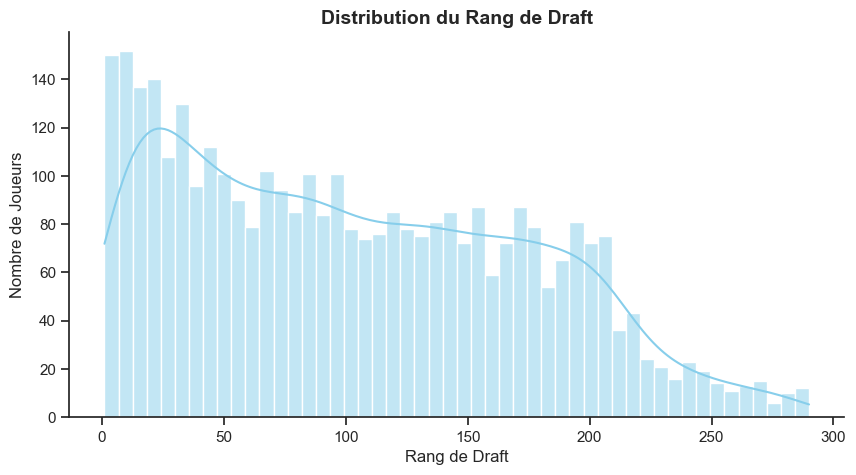

In [ ]:
# 1. On définit un style minimaliste
sns.set_theme(style="ticks")

plt.figure(figsize=(10, 5))

# 2. L'histogramme avec une couleur douce et une courbe de densité
sns.histplot(df_imp["DRAFT_OVERALL"], bins=50, kde=True, color="skyblue", edgecolor="white")

# 3. On simplifie l'habillage
plt.title("Distribution du Rang de Draft", fontsize=14, fontweight='bold')
plt.xlabel("Rang de Draft")
plt.ylabel("Nombre de Joueurs")

# 4. On enlève les bordures inutiles pour un look "pro"
sns.despine()

plt.show()

### Distribution des variables clés

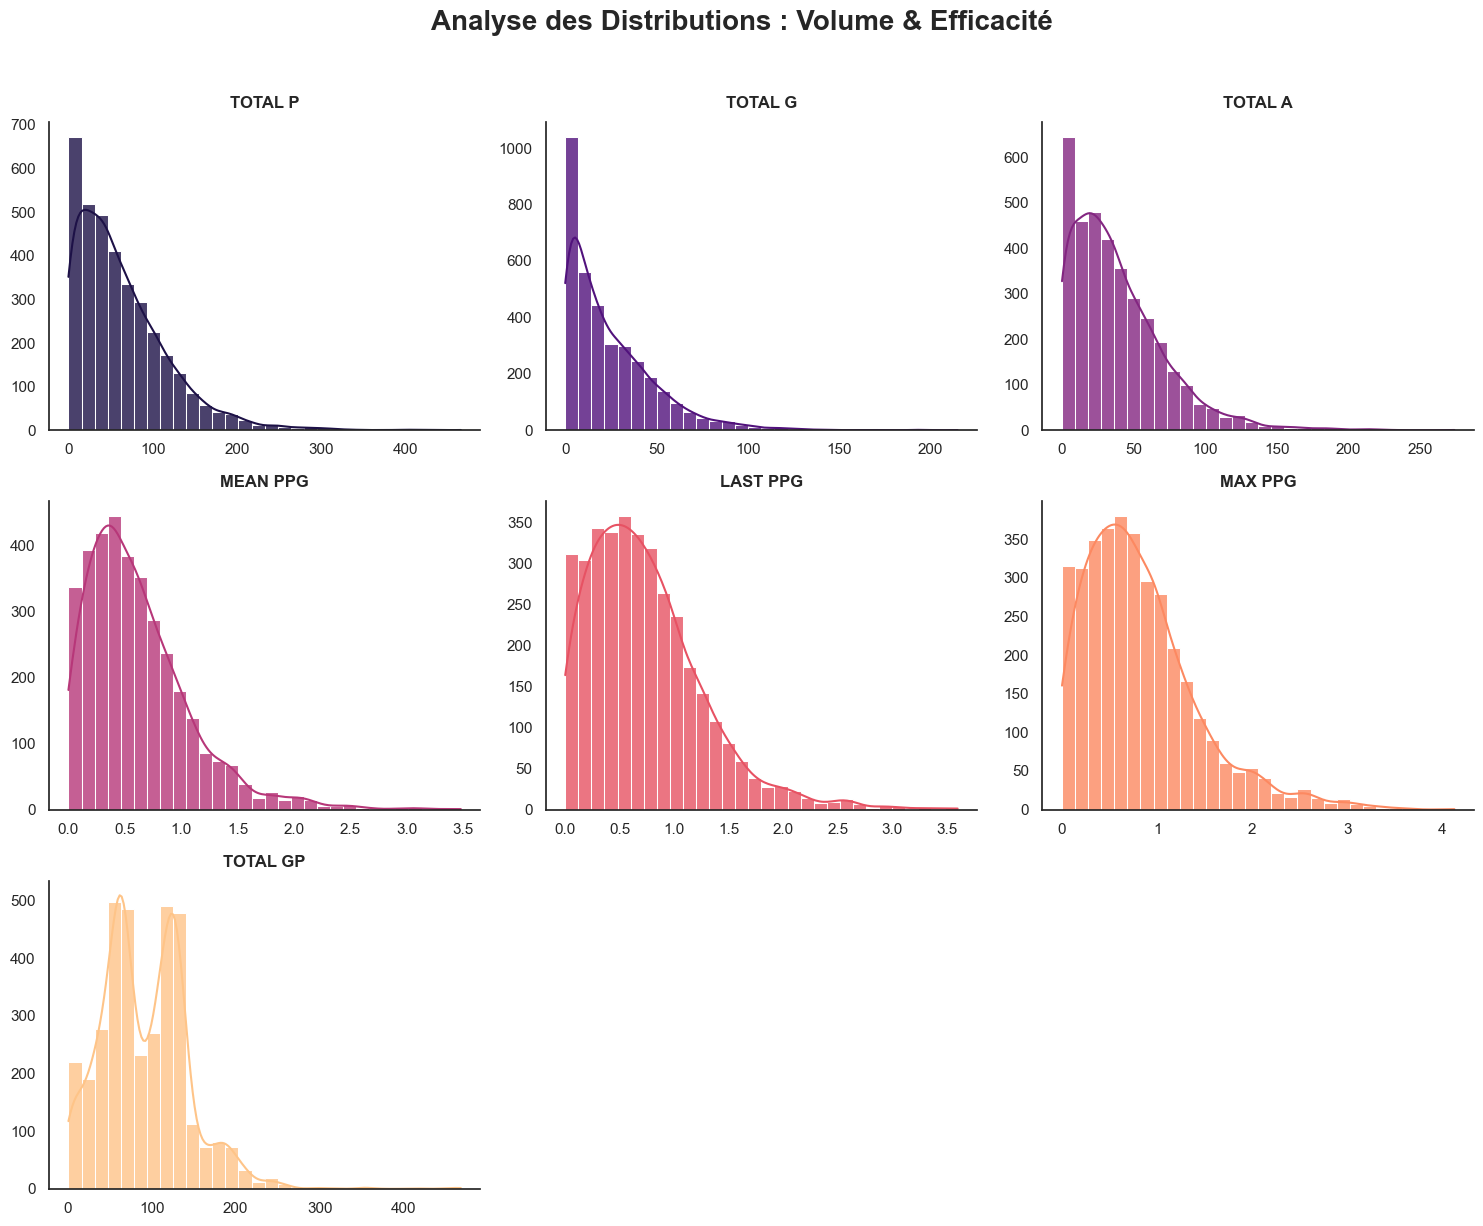

In [ ]:
# 1. Configuration du style global
sns.set_theme(style="white", palette="magma")
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# 2. Boucle optimisée
for i, col in enumerate(cols):
    # On utilise un dégradé différent pour chaque histogramme
    sns.histplot(df_imp[col], bins=30, kde=True, ax=axes[i], 
                 color=sns.color_palette("magma", len(cols))[i],
                 edgecolor="white", alpha=0.8)
    
    # Titres plus propres (on remplace les underscores par des espaces)
    axes[i].set_title(col.replace("_", " "), fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
    # Désencombrer chaque sous-graphique
    sns.despine(ax=axes[i])

# 3. Nettoyage des axes vides
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

# 4. Titre principal et ajustement
plt.suptitle("Analyse des Distributions : Volume & Efficacité", 
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##  Corrélations

C:\Users\User\AppData\Local\Temp\ipykernel_20384\2051733150.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


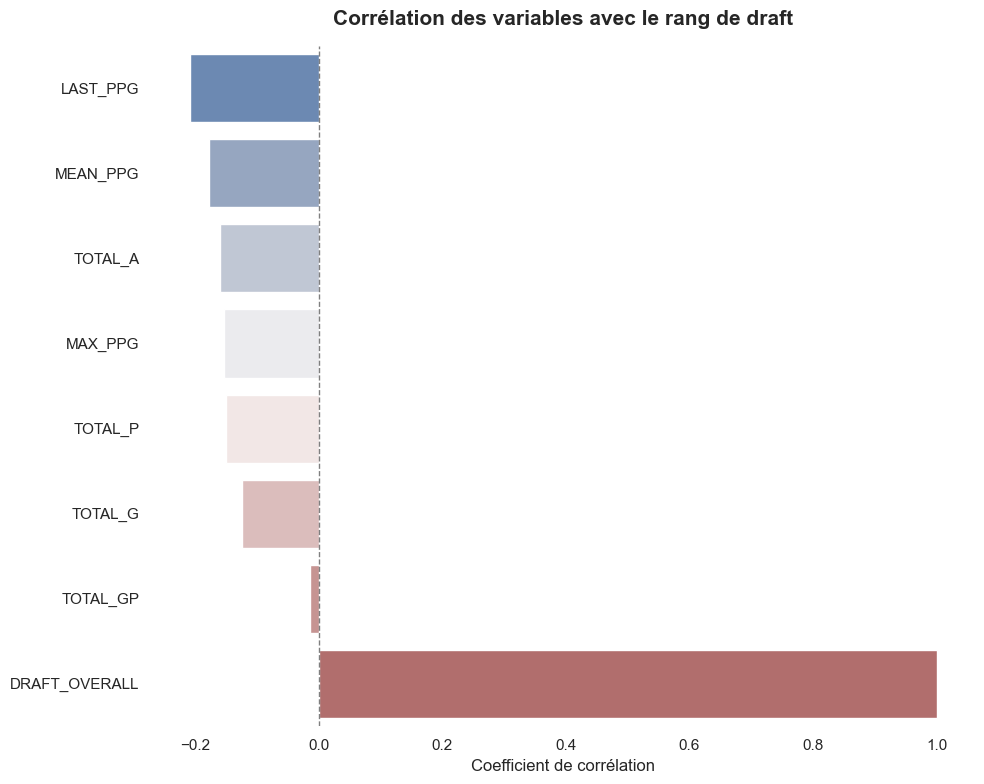

In [98]:
# 1. Calcul de la corrélation
corr_with_target = df_imp.corr(numeric_only=True)["DRAFT_OVERALL"].sort_values()

plt.figure(figsize=(10, 8)) # Un peu plus haut pour mieux lire les variables

# 2. Amélioration des couleurs : Palette divergente "vlag"
# Elle met automatiquement du bleu pour les valeurs négatives et du rouge pour les positives
sns.barplot(
    x=corr_with_target.values,
    y=corr_with_target.index,
    palette="vlag" 
)

# 3. Habillage épuré
plt.title("Corrélation des variables avec le rang de draft", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Coefficient de corrélation", fontsize=12)
plt.ylabel("") # On enlève le label "Variables" pour alléger

# Ligne de repère à zéro plus discrète
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Suppression des bordures inutiles
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

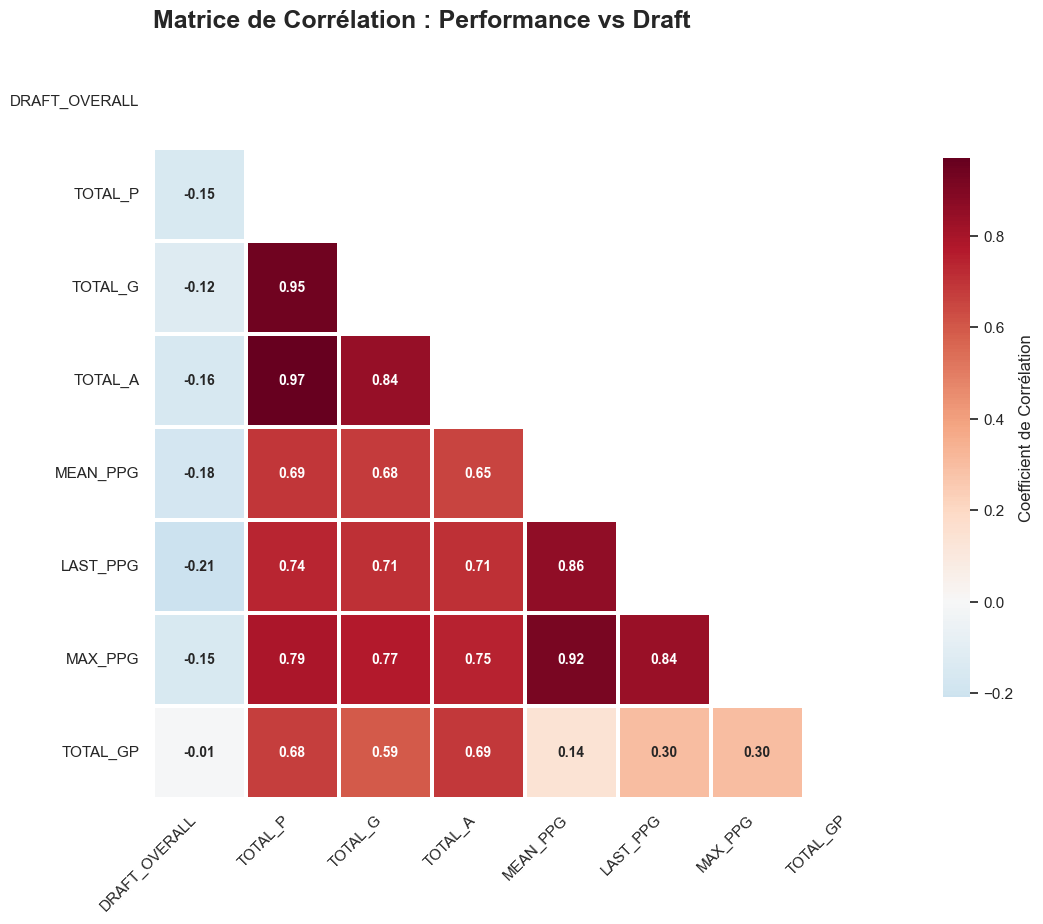

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcul de la matrice
cols = ["DRAFT_OVERALL", "TOTAL_P", "TOTAL_G", "TOTAL_A", "MEAN_PPG", "LAST_PPG", "MAX_PPG", "TOTAL_GP"]
corr_matrix = df_imp[cols].corr()

# 2. Masque pour le triangle supérieur
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Configuration esthétique
plt.figure(figsize=(12, 10))

# On utilise une palette divergente plus moderne : "RdBu_r" ou "vlag"
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",          # Rouge pour positif, Bleu pour négatif (inversé pour la draft)
    center=0,
    linewidths=1.5,         # Lignes plus épaisses pour un look "grille"
    cbar_kws={"shrink": .7, "label": "Coefficient de Corrélation"}, # Barre de couleur plus fine
    square=True,            # Force des carrés parfaits
    annot_kws={"size": 10, "weight": "bold"} # Chiffres en gras et lisibles
)

# 4. Raffinement des labels
plt.title("Matrice de Corrélation : Performance vs Draft", 
          fontsize=18, fontweight='bold', pad=20, loc='left')

# Rotation des labels pour une lecture plus fluide
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# On retire le cadre extérieur pour plus de légèreté
sns.despine(left=True, bottom=True)

plt.show()

## Visualisations principales

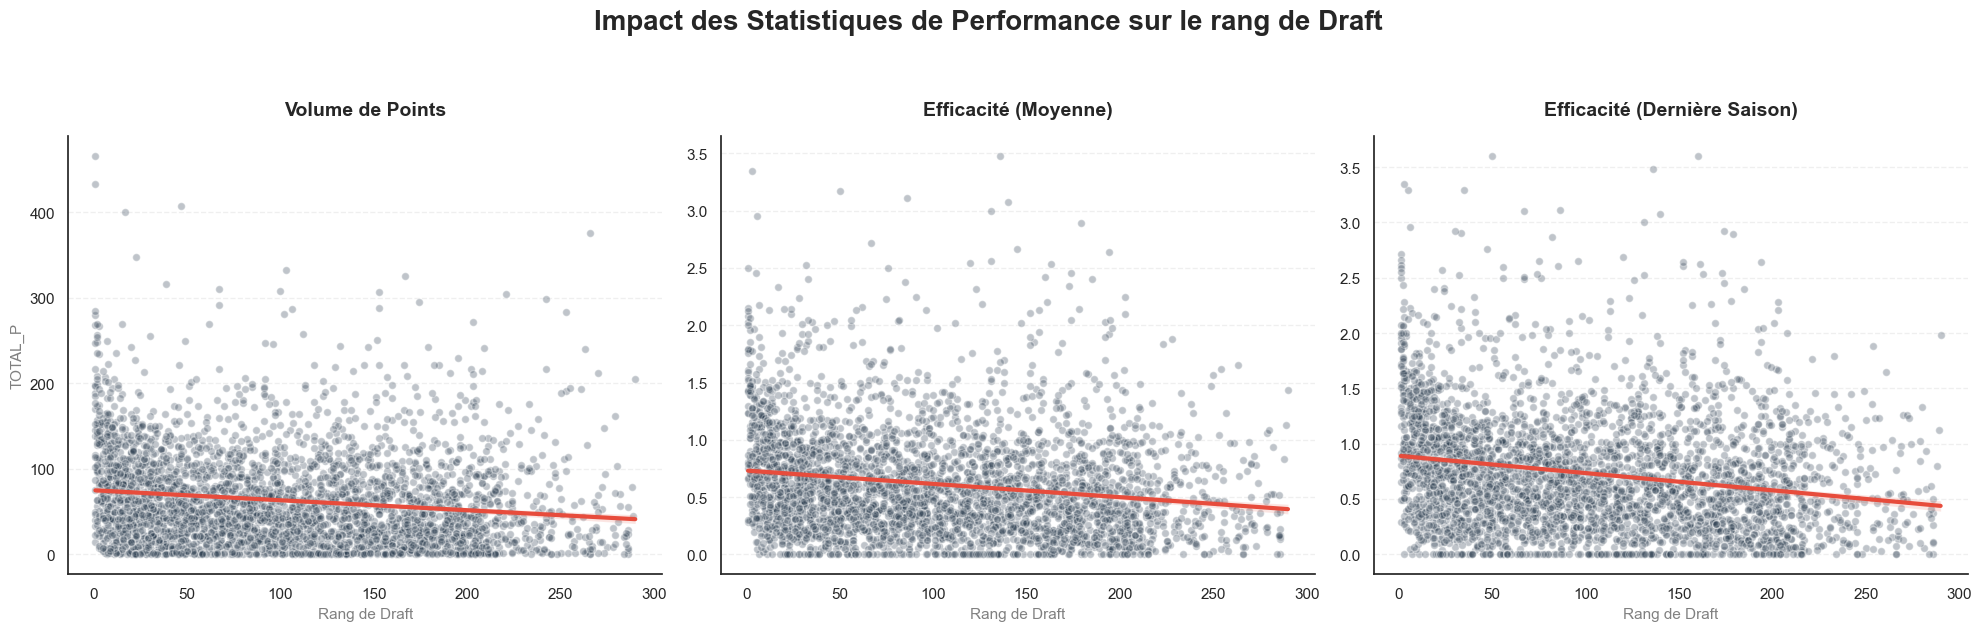

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Style et palette
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)

# Configuration des variables
cols = ["TOTAL_P", "MEAN_PPG", "LAST_PPG"]
titles = ["Volume de Points", "Efficacité (Moyenne)", "Efficacité (Dernière Saison)"]

for i, col in enumerate(cols):
    # Inversion : X = Draft, Y = Stat
    sns.regplot(
        data=df_imp,
        x="DRAFT_OVERALL",
        y=col,
        scatter_kws={'alpha':0.3, 's':30, 'color':'#2c3e50', 'edgecolor':'white'},
        line_kws={'color':'#e74c3c', 'lw':3},
        ax=axes[i]
    )
    
    # Personnalisation de chaque sous-graphique
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel("Rang de Draft", fontsize=11, color="gray")
    axes[i].set_ylabel(col if i == 0 else "", fontsize=11, color="gray")
    
    # On inverse l'axe X pour que le n°1 soit à gauche (le "meilleur")
    # axes[i].invert_xaxis() # Optionnel si vous voulez le 1 à droite, mais le 1 à gauche est plus intuitif
    
    sns.despine(ax=axes[i])
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

# Titre général
plt.suptitle("Impact des Statistiques de Performance sur le rang de Draft ", 
             fontsize=20, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

##  Régressions linéaires simples

On compare directement :
- un modèle **volume**
- un modèle **efficacité**

In [102]:
y = df_imp["DRAFT_OVERALL"]

# Modèle volume
X_vol = df_imp[["TOTAL_P"]]
model_vol = LinearRegression().fit(X_vol, y)
pred_vol = model_vol.predict(X_vol)
r2_vol = r2_score(y, pred_vol)

# Modèle efficacité
X_eff = df_imp[["MEAN_PPG"]]
model_eff = LinearRegression().fit(X_eff, y)
pred_eff = model_eff.predict(X_eff)
r2_eff = r2_score(y, pred_eff)

print("R² volume (TOTAL_P):", r2_vol)
print("Coefficient volume:", model_vol.coef_[0])
print()
print("R² efficacité (MEAN_PPG):", r2_eff)
print("Coefficient efficacité:", model_eff.coef_[0])

R² volume (TOTAL_P): 0.022601835040502727
Coefficient volume: -0.19385644298553095

R² efficacité (MEAN_PPG): 0.031288646309660995
Coefficient efficacité: -26.933680561294306


In [49]:
# Dernière saison
X_last = df_imp[["LAST_PPG"]]
model_last = LinearRegression().fit(X_last, y)
pred_last = model_last.predict(X_last)
r2_last = r2_score(y, pred_last)

# Pic d'efficacité
X_max = df_imp[["MAX_PPG"]]
model_max = LinearRegression().fit(X_max, y)
pred_max = model_max.predict(X_max)
r2_max = r2_score(y, pred_max)

print("R² LAST_PPG:", r2_last)
print("Coefficient LAST_PPG:", model_last.coef_[0])
print()
print("R² MAX_PPG:", r2_max)
print("Coefficient MAX_PPG:", model_max.coef_[0])

R² LAST_PPG: 0.04333653908346147
Coefficient LAST_PPG: -27.790159626667542

R² MAX_PPG: 0.023589064791732728
Coefficient MAX_PPG: -18.081747159297812


##  Modèles combinés

In [50]:
# Volume + contrôle
X_vol_ctrl = df_imp[["TOTAL_P", "TOTAL_GP"]]
model_vol_ctrl = LinearRegression().fit(X_vol_ctrl, y)
pred_vol_ctrl = model_vol_ctrl.predict(X_vol_ctrl)
r2_vol_ctrl = r2_score(y, pred_vol_ctrl)

# Efficacité + contrôle
X_eff_ctrl = df_imp[["MEAN_PPG", "TOTAL_GP"]]
model_eff_ctrl = LinearRegression().fit(X_eff_ctrl, y)
pred_eff_ctrl = model_eff_ctrl.predict(X_eff_ctrl)
r2_eff_ctrl = r2_score(y, pred_eff_ctrl)

print("R² volume + contrôle:", r2_vol_ctrl)
print(pd.Series(model_vol_ctrl.coef_, index=X_vol_ctrl.columns))
print()
print("R² efficacité + contrôle:", r2_eff_ctrl)
print(pd.Series(model_eff_ctrl.coef_, index=X_eff_ctrl.columns))

R² volume + contrôle: 0.036973654552249324
TOTAL_P    -0.335373
TOTAL_GP    0.222214
dtype: float64

R² efficacité + contrôle: 0.031423212625076746
MEAN_PPG   -27.181521
TOTAL_GP     0.016015
dtype: float64


In [51]:
# Modèle complet
X_full = df_imp[["TOTAL_P", "MEAN_PPG", "LAST_PPG", "MAX_PPG", "TOTAL_GP"]]
model_full = LinearRegression().fit(X_full, y)
pred_full = model_full.predict(X_full)
r2_full = r2_score(y, pred_full)

print("R² modèle complet:", r2_full)
pd.Series(model_full.coef_, index=X_full.columns).sort_values(key=np.abs, ascending=False)

R² modèle complet: 0.05308535668275027


LAST_PPG   -31.564554
MAX_PPG     19.813331
MEAN_PPG    -2.087737
TOTAL_P     -0.249770
TOTAL_GP     0.191659
dtype: float64

##  Tableau récapitulatif

In [52]:
results = pd.DataFrame({
    "Modèle": [
        "Volume (TOTAL_P)",
        "Efficacité (MEAN_PPG)",
        "Dernière saison (LAST_PPG)",
        "Pic (MAX_PPG)",
        "Volume + contrôle",
        "Efficacité + contrôle",
        "Modèle complet"
    ],
    "R2": [
        r2_vol,
        r2_eff,
        r2_last,
        r2_max,
        r2_vol_ctrl,
        r2_eff_ctrl,
        r2_full
    ]
}).sort_values("R2", ascending=False)

results

,Modèle,R2
6,Modèle complet,0.053085
2,Dernière saison (LAST_PPG),0.043337
4,Volume + contrôle,0.036974
5,Efficacité + contrôle,0.031423
1,Efficacité (MEAN_PPG),0.031289
3,Pic (MAX_PPG),0.023589
0,Volume (TOTAL_P),0.022602
